# 02 — LightGBM WFO (v3): Fixed-Horizon Walk-Forward Optimization

**Task ID:** `MODEL-LGBM-WFO-V3-006`  
**Target:** Fixed Horizon (>0.3% in 6h) — winner from V2 (AUC = 0.571)  
**Tearsheet:** `src/hmats/evaluation/reporting.py` (v8-style layout)  
**Artifacts:** `artifacts/02_lgbm_omni_0fee_v3/`  

## Research question

> Which training-window length best captures Bitcoin's regime shifts?
> Does 2018 data still inform 2025, or does the market forget its own history?

## WFO Schemes Evaluated

| ID | Name | Train window | Hypothesis |
|----|------|-------------|------------|
| EXP | Expanding | All past data up to T | Historical structure regimes are stable |
| L2Y | 2-Year Sliding | Rolling 24 months | Smooth regime adaptation |
| M1Y | 1-Year Sliding | Rolling 12 months | Faster adaptation, less noise |
| S3M | 3-Month Sliding | Rolling 3 months | Hyper-local; risks low sample count |

**Embargo:** 72-bar gap (6h) at each boundary — prevents FH label leakage into training.  
**OOS period:** 2024-01-01 → 2026-05-27 (test set un-blinded).

In [27]:
import json
import sys
import time
import warnings
from pathlib import Path

import lightgbm as lgb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore', category=UserWarning)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Fixed Horizon target (V2 winner) ─────────────────────────────────────
FH_HORIZON   = 72      # 6h at 5m
FH_THRESHOLD = 0.003   # >0.3% forward return

# ── Best LGBM params — locked from V2 fixed_horizon grid winner ──────────
# V2 result: num_leaves=15, max_depth=8, lr=0.05, colsample=0.5 → AUC=0.5713
BEST_PARAMS = {
    'num_leaves':       15,
    'max_depth':        8,
    'learning_rate':    0.05,
    'colsample_bytree': 0.5,
}
BASE_LGB_PARAMS = dict(
    objective         = 'binary',
    metric            = 'auc',
    verbose           = -1,
    n_jobs            = -1,
    seed              = 42,
    n_estimators      = 300,   # fixed, no early stopping — consistent across windows
    min_child_samples = 50,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
)
WFO_PARAMS = {**BASE_LGB_PARAMS, **BEST_PARAMS}

# ── WFO settings ─────────────────────────────────────────────────────────
EMBARGO_BARS   = FH_HORIZON                              # = label lookahead window
EMBARGO_DUR    = pd.Timedelta(minutes=5 * EMBARGO_BARS)  # 6h
MIN_TRAIN_BARS = 5_000                                   # skip window if train set too small
OOS_START      = pd.Timestamp('2024-01-01', tz='UTC')
WFO_THRESHOLD  = 0.75                                    # high-conviction signal gate

print(f'Fixed Horizon : {FH_HORIZON} bars ({FH_HORIZON*5}min)  threshold={FH_THRESHOLD:.1%}')
print(f'Best params   : {BEST_PARAMS}')
print(f'Embargo       : {EMBARGO_BARS} bars = {EMBARGO_DUR}')
print(f'OOS start     : {OOS_START.date()}')
print(f'Signal gate   : p > {WFO_THRESHOLD}')

Fixed Horizon : 72 bars (360min)  threshold=0.3%
Best params   : {'num_leaves': 15, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.5}
Embargo       : 72 bars = 0 days 06:00:00
OOS start     : 2024-01-01
Signal gate   : p > 0.75


In [28]:
import importlib

def find_repo_root() -> Path:
    p = Path.cwd()
    while p != p.parent:
        if (p / 'pyproject.toml').exists():
            return p
        p = p.parent
    raise RuntimeError('pyproject.toml not found')

REPO_ROOT    = find_repo_root()
RAW_DIR      = REPO_ROOT / 'data' / 'raw'
FEATURES_DIR = REPO_ROOT / 'data' / 'features'
CACHE_DIR    = REPO_ROOT / 'data' / 'cache'

# Artifacts: notebook-specific folder at repo root (lab/figures is obsolete alpha work)
ARTIFACTS_DIR = REPO_ROOT / 'artifacts' / '02_lgbm_omni_0fee_v3'
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

OHLCV_5M_PATH  = RAW_DIR      / 'BTCUSDT_5m.parquet'
FEATURES_CLEAN = FEATURES_DIR / 'BTCUSDT_5m_structural_clean.parquet'
REGISTRY_PATH  = FEATURES_DIR / 'feature_registry_v2.json'

# Always reload from disk — avoids stale-module errors after reporting.py edits
sys.path.insert(0, str(REPO_ROOT / 'src'))
import hmats.evaluation.reporting as _reporting_mod
importlib.reload(_reporting_mod)
from hmats.evaluation.reporting import generate_tearsheet, _equity_from_trades

print(f'REPO_ROOT     : {REPO_ROOT}')
print(f'ARTIFACTS_DIR : {ARTIFACTS_DIR}')
print(f'Clean feats   : {FEATURES_CLEAN.exists()}')
print(f'reporting.py  : loaded OK  (generate_tearsheet params: '
      f'{list(__import__("inspect").signature(generate_tearsheet).parameters.keys())})')

REPO_ROOT     : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system
ARTIFACTS_DIR : /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3
Clean feats   : True
reporting.py  : loaded OK  (generate_tearsheet params: ['trades_df', 'price_df', 'prob_series', 'params', 'metrics', 'title', 'fig_size', 'save_path'])


## Data Loading & Feature Assembly

In [18]:
print('Loading OHLCV (5m) ...')
df_raw = pd.read_parquet(OHLCV_5M_PATH,
                         columns=['open', 'high', 'low', 'close', 'volume'])
if df_raw.index.tz is None:
    df_raw.index = df_raw.index.tz_localize('UTC')

print('Loading clean structural features (V1 patch applied) ...')
df_struct = pd.read_parquet(FEATURES_CLEAN)
with open(REGISTRY_PATH) as f:
    registry = json.load(f)
STRUCT_FEATURES = registry['ablation_subsets']['all']

print(f'  5m bars  : {len(df_raw):,}  {df_raw.index[0].date()} -> {df_raw.index[-1].date()}')
print(f'  Features : {len(STRUCT_FEATURES)} structural')

Loading OHLCV (5m) ...
Loading clean structural features (V1 patch applied) ...
  5m bars  : 923,248  2017-08-17 -> 2026-05-27
  Features : 39 structural


In [19]:
def build_momentum_features(df5m: pd.DataFrame) -> pd.DataFrame:
    """4 safe momentum features, all shift(1)-guarded."""
    close  = df5m['close']
    volume = df5m['volume']
    feats  = pd.DataFrame(index=df5m.index, dtype='float32')
    for n_bars, tag in [(3, '15m'), (6, '30m'), (12, '1h')]:
        feats[f'mom_ret_{tag}'] = close.pct_change(n_bars).shift(1).astype('float32')
    vol_diff  = volume.diff(1)
    vol_std   = volume.rolling(72, min_periods=36).std() + 1e-8
    vol_slope = vol_diff.rolling(5, min_periods=3).mean() / vol_std
    feats['mom_vol_slope_5bar'] = vol_slope.shift(1).clip(-5, 5).astype('float32')
    return feats

df_mom = build_momentum_features(df_raw)
MOM_FEATURES = df_mom.columns.tolist()
print(f'Momentum features built: {MOM_FEATURES}')

Momentum features built: ['mom_ret_15m', 'mom_ret_30m', 'mom_ret_1h', 'mom_vol_slope_5bar']


In [20]:
# Inner join: OHLCV + structural + momentum
df_base = df_raw.join(df_struct, how='inner').join(df_mom, how='inner')
df_base.dropna(subset=STRUCT_FEATURES, inplace=True)

# Fixed-Horizon label
fwd_close           = df_base['close'].shift(-FH_HORIZON)
df_base['label_fh'] = ((fwd_close / df_base['close'] - 1) > FH_THRESHOLD).astype('int8')
df_base             = df_base.dropna(subset=['label_fh'])

ALL_FEATURES = STRUCT_FEATURES + MOM_FEATURES

print(f'Dataset   : {len(df_base):,} bars  '
      f'{df_base.index[0].date()} -> {df_base.index[-1].date()}')
print(f'Features  : {len(ALL_FEATURES)} ({len(STRUCT_FEATURES)} struct + {len(MOM_FEATURES)} mom)')
print(f'Label pos : {df_base["label_fh"].mean():.3f}  '
      f'({int(df_base["label_fh"].sum()):,} positive bars)')

Dataset   : 920,748 bars  2017-08-25 -> 2026-05-27
Features  : 43 (39 struct + 4 mom)
Label pos : 0.370  (340,682 positive bars)


## WFO Engine

One LGBM model per monthly test window × 4 schemes ≈ **116 fits** (~3–6 min total).  
Parameters are frozen to V2's best configuration — no grid search here.

In [21]:
OOS_END = df_base.index[-1]

WFO_SCHEMES = {
    'expanding':  {'type': 'expanding', 'months': None, 'label': 'Expanding (all history)'},
    'long_2yr':   {'type': 'sliding',   'months': 24,   'label': '2-Year Sliding'},
    'medium_1yr': {'type': 'sliding',   'months': 12,   'label': '1-Year Sliding'},
    'short_3mo':  {'type': 'sliding',   'months': 3,    'label': '3-Month Sliding'},
}

def make_monthly_windows(start, end):
    windows = []
    cur = start
    while cur < end:
        nxt = cur + pd.DateOffset(months=1)
        windows.append((cur, min(nxt, end)))
        cur = nxt
    return windows

windows = make_monthly_windows(OOS_START, OOS_END)
print(f'OOS period  : {OOS_START.date()} -> {OOS_END.date()}')
print(f'Monthly windows : {len(windows)}')
print(f'Total fits      : {len(windows) * len(WFO_SCHEMES)}')

OOS period  : 2024-01-01 -> 2026-05-27
Monthly windows : 29
Total fits      : 116


In [22]:
def run_wfo(scheme_key: str, scheme: dict) -> pd.Series:
    """
    Walk-forward loop for one training-window scheme.

    For each monthly test window:
      1. Define training data according to scheme (expanding or sliding).
      2. Apply embargo: last training bar is EMBARGO_DUR before test_start.
      3. Train a fresh LGBMClassifier on train data.
      4. Predict P(TP) on every bar in the test window.

    Returns
    -------
    pd.Series of P(TP) indexed by bar timestamp (OOS period only).
    """
    all_probs: dict = {}
    skipped   = 0
    t0        = time.perf_counter()

    for i, (test_start, test_end) in enumerate(windows):
        # Embargo: drop training bars whose FH label uses test-period close prices
        cutoff = test_start - EMBARGO_DUR

        if scheme['type'] == 'expanding':
            df_train = df_base[df_base.index < cutoff]
        else:
            win_start = cutoff - pd.DateOffset(months=scheme['months'])
            df_train  = df_base[
                (df_base.index >= win_start) & (df_base.index < cutoff)
            ]

        df_test = df_base[
            (df_base.index >= test_start) & (df_base.index < test_end)
        ]

        if len(df_train) < MIN_TRAIN_BARS or len(df_test) == 0:
            skipped += 1
            continue

        X_tr = df_train[ALL_FEATURES].values.astype('float32')
        y_tr = df_train['label_fh'].values
        X_te = df_test[ALL_FEATURES].values.astype('float32')

        m = lgb.LGBMClassifier(**WFO_PARAMS)
        m.fit(X_tr, y_tr)
        probs = m.predict_proba(X_te)[:, 1]

        for ts, p in zip(df_test.index, probs):
            all_probs[ts] = p

        if (i + 1) % 6 == 0 or i == len(windows) - 1:
            elapsed = time.perf_counter() - t0
            print(f'  [{scheme_key}] {i+1}/{len(windows)}  '
                  f'train={len(df_train):,}  test={len(df_test):,}  '
                  f'({elapsed:.0f}s)', flush=True)

    elapsed = time.perf_counter() - t0
    print(f'  [{scheme_key}] DONE — {len(all_probs):,} predictions  '
          f'skipped={skipped}  {elapsed:.1f}s')
    return pd.Series(all_probs, name='prob').sort_index()


def fh_backtest(df_bt: pd.DataFrame,
                probs: np.ndarray,
                threshold: float) -> pd.DataFrame:
    """
    Zero-fee fixed-horizon backtest with no-overlap constraint.

    At each bar where p > threshold (and no position is open),
    enter long. Exit after FH_HORIZON bars. Record P&L.
    """
    close_arr = df_bt['close'].values.astype('float64')
    index_arr = df_bt.index
    n         = len(df_bt)

    sig_idx = np.where(probs > threshold)[0]
    if len(sig_idx) == 0:
        return pd.DataFrame()

    trades    = []
    last_exit = -1

    for i in sig_idx:
        if i <= last_exit:
            continue
        dur      = min(FH_HORIZON, n - 1 - i)
        exit_bar = i + dur
        pnl      = (close_arr[exit_bar] - close_arr[i]) / close_arr[i]
        last_exit = i + FH_HORIZON

        trades.append({
            'entry_time':    index_arr[i],
            'exit_time':     index_arr[exit_bar],
            'direction':     'long',
            'outcome':       'FH',
            'pnl_pct':       pnl,
            'prob':          probs[i],
            'duration_bars': dur,
        })

    if not trades:
        return pd.DataFrame()
    return pd.DataFrame(trades).set_index('entry_time')

## Run All 4 WFO Schemes

Each scheme trains ~29 monthly models (one per test window). Total ≈ 116 fits.  
Expected runtime: **3–6 minutes** on Apple M-series.

In [23]:
wfo_results = {}
t_all = time.perf_counter()

for scheme_key, scheme in WFO_SCHEMES.items():
    print(f'\n{"="*60}')
    print(f'Scheme : {scheme["label"]}')
    print(f'{"="*60}')
    probs_series = run_wfo(scheme_key, scheme)
    wfo_results[scheme_key] = {'probs': probs_series, 'scheme': scheme}

print(f'\nAll schemes done in {(time.perf_counter()-t_all)/60:.1f} min')


Scheme : Expanding (all history)
  [expanding] 6/29  train=711,620  test=8,640  (17s)
  [expanding] 12/29  train=764,324  test=8,928  (34s)
  [expanding] 18/29  train=816,740  test=8,640  (50s)
  [expanding] 24/29  train=869,444  test=8,928  (67s)
  [expanding] 29/29  train=912,932  test=7,743  (82s)
  [expanding] DONE — 252,831 predictions  skipped=0  81.9s

Scheme : 2-Year Sliding
  [long_2yr] 6/29  train=210,528  test=8,640  (10s)
  [long_2yr] 12/29  train=210,528  test=8,928  (20s)
  [long_2yr] 18/29  train=210,528  test=8,640  (30s)
  [long_2yr] 24/29  train=210,528  test=8,928  (40s)
  [long_2yr] 29/29  train=210,240  test=7,743  (48s)
  [long_2yr] DONE — 252,831 predictions  skipped=0  48.4s

Scheme : 1-Year Sliding
  [medium_1yr] 6/29  train=105,408  test=8,640  (9s)
  [medium_1yr] 12/29  train=105,408  test=8,928  (18s)
  [medium_1yr] 18/29  train=105,120  test=8,640  (26s)
  [medium_1yr] 24/29  train=105,120  test=8,928  (35s)
  [medium_1yr] 29/29  train=105,120  test=7,743 

## OOS Evaluation — AUC, Backtest, Tearsheet

For each scheme:
1. Align predictions to OOS index → compute AUC.
2. Run `fh_backtest` at `p > 0.75`.
3. Compute `params` / `metrics` dicts and call `generate_tearsheet`.

In [24]:
import math

# OOS ground truth slice
df_oos   = df_base[df_base.index >= OOS_START].copy()
y_oos    = df_oos['label_fh'].values
price_oos = df_oos[['close']]

print(f'OOS dataset : {len(df_oos):,} bars  '
      f'{df_oos.index[0].date()} -> {df_oos.index[-1].date()}')
print(f'OOS pos_rate: {y_oos.mean():.3f}')
print()

summary_rows = []

for scheme_key, res in wfo_results.items():
    scheme    = res['scheme']
    probs_s   = res['probs']

    # Align to OOS index
    probs_aligned = probs_s.reindex(df_oos.index).values.astype('float64')
    valid         = ~np.isnan(probs_aligned)

    # OOS AUC
    auc = (roc_auc_score(y_oos[valid], probs_aligned[valid])
           if valid.sum() > 100 else float('nan'))

    # Signal count above threshold
    n_signals = int((np.nan_to_num(probs_aligned) > WFO_THRESHOLD).sum())

    # Backtest
    probs_clean = np.nan_to_num(probs_aligned, nan=0.0)
    trades      = fh_backtest(df_oos, probs_clean, WFO_THRESHOLD)

    n_trades = len(trades)

    if trades.empty:
        ev = wr = tot_ret = max_dd = sharpe = pf = tpd = float('nan')
    else:
        pnl      = trades['pnl_pct'].values.astype(float)
        ev       = float(pnl.mean() * 100)
        wr       = float((pnl > 0).mean() * 100)
        tot_ret  = float(np.prod(1 + pnl) - 1)
        pk       = np.maximum.accumulate(np.cumprod(1 + pnl))
        max_dd   = float(((np.cumprod(1 + pnl) - pk) / (pk + 1e-12)).min())
        t0_t, t1_t = trades.index[0], trades.index[-1]
        n_days   = max((t1_t - t0_t).total_seconds() / 86400, 1)
        tpd      = n_trades / n_days
        sd       = float(pnl.std(ddof=1)) if n_trades > 1 else 1e-9
        sharpe   = float(pnl.mean() / sd * math.sqrt(tpd * 252))
        gp = pnl[pnl > 0].sum() if (pnl > 0).any() else 0.0
        gl = abs(pnl[pnl < 0].sum()) if (pnl < 0).any() else 1e-9
        pf = float(gp / gl)

    fill_rate = n_trades / max(n_signals, 1)

    # ── Store for comparison ──────────────────────────────────────────────
    wfo_results[scheme_key]['trades']         = trades
    wfo_results[scheme_key]['probs_aligned']  = probs_aligned
    wfo_results[scheme_key]['auc']            = auc
    wfo_results[scheme_key]['n_signals']      = n_signals

    summary_rows.append(dict(
        scheme=scheme_key, label=scheme['label'],
        oos_auc=auc, n_signals=n_signals,
        n_trades=n_trades, fill_rate=fill_rate,
        win_rate_pct=wr, ev_per_trade_pct=ev,
        total_return_pct=tot_ret * 100 if not math.isnan(tot_ret) else float('nan'),
        max_dd_pct=max_dd * 100 if not math.isnan(max_dd) else float('nan'),
        sharpe=sharpe, profit_factor=pf,
    ))

    cvg = valid.mean() * 100
    print(f'[{scheme_key:12s}] AUC={auc:.5f}  n_trades={n_trades:4d}  '
          f'EV={ev:+.4f}%  WR={wr:.1f}%  fill={fill_rate:.1%}  coverage={cvg:.1f}%')

summary_df = pd.DataFrame(summary_rows).set_index('scheme')
print()
print(summary_df[[
    'oos_auc', 'n_trades', 'ev_per_trade_pct',
    'total_return_pct', 'max_dd_pct', 'sharpe'
]].to_string())

OOS dataset : 252,832 bars  2024-01-01 -> 2026-05-27
OOS pos_rate: 0.355

[expanding   ] AUC=0.57496  n_trades=   0  EV=+nan%  WR=nan%  fill=0.0%  coverage=100.0%
[long_2yr    ] AUC=0.56217  n_trades=  35  EV=+0.4832%  WR=65.7%  fill=4.2%  coverage=100.0%
[medium_1yr  ] AUC=0.55224  n_trades= 117  EV=+0.4612%  WR=61.5%  fill=4.7%  coverage=100.0%
[short_3mo   ] AUC=0.52923  n_trades= 586  EV=+0.1386%  WR=57.3%  fill=3.5%  coverage=100.0%

            oos_auc  n_trades  ev_per_trade_pct  total_return_pct  max_dd_pct  sharpe
scheme                                                                               
expanding    0.5750         0               NaN               NaN         NaN     NaN
long_2yr     0.5622        35            0.4832           16.3653    -11.0561  0.6123
medium_1yr   0.5522       117            0.4612           66.0753    -15.2452  1.2038
short_3mo    0.5292       586            0.1386          107.8093    -28.7526  1.0891


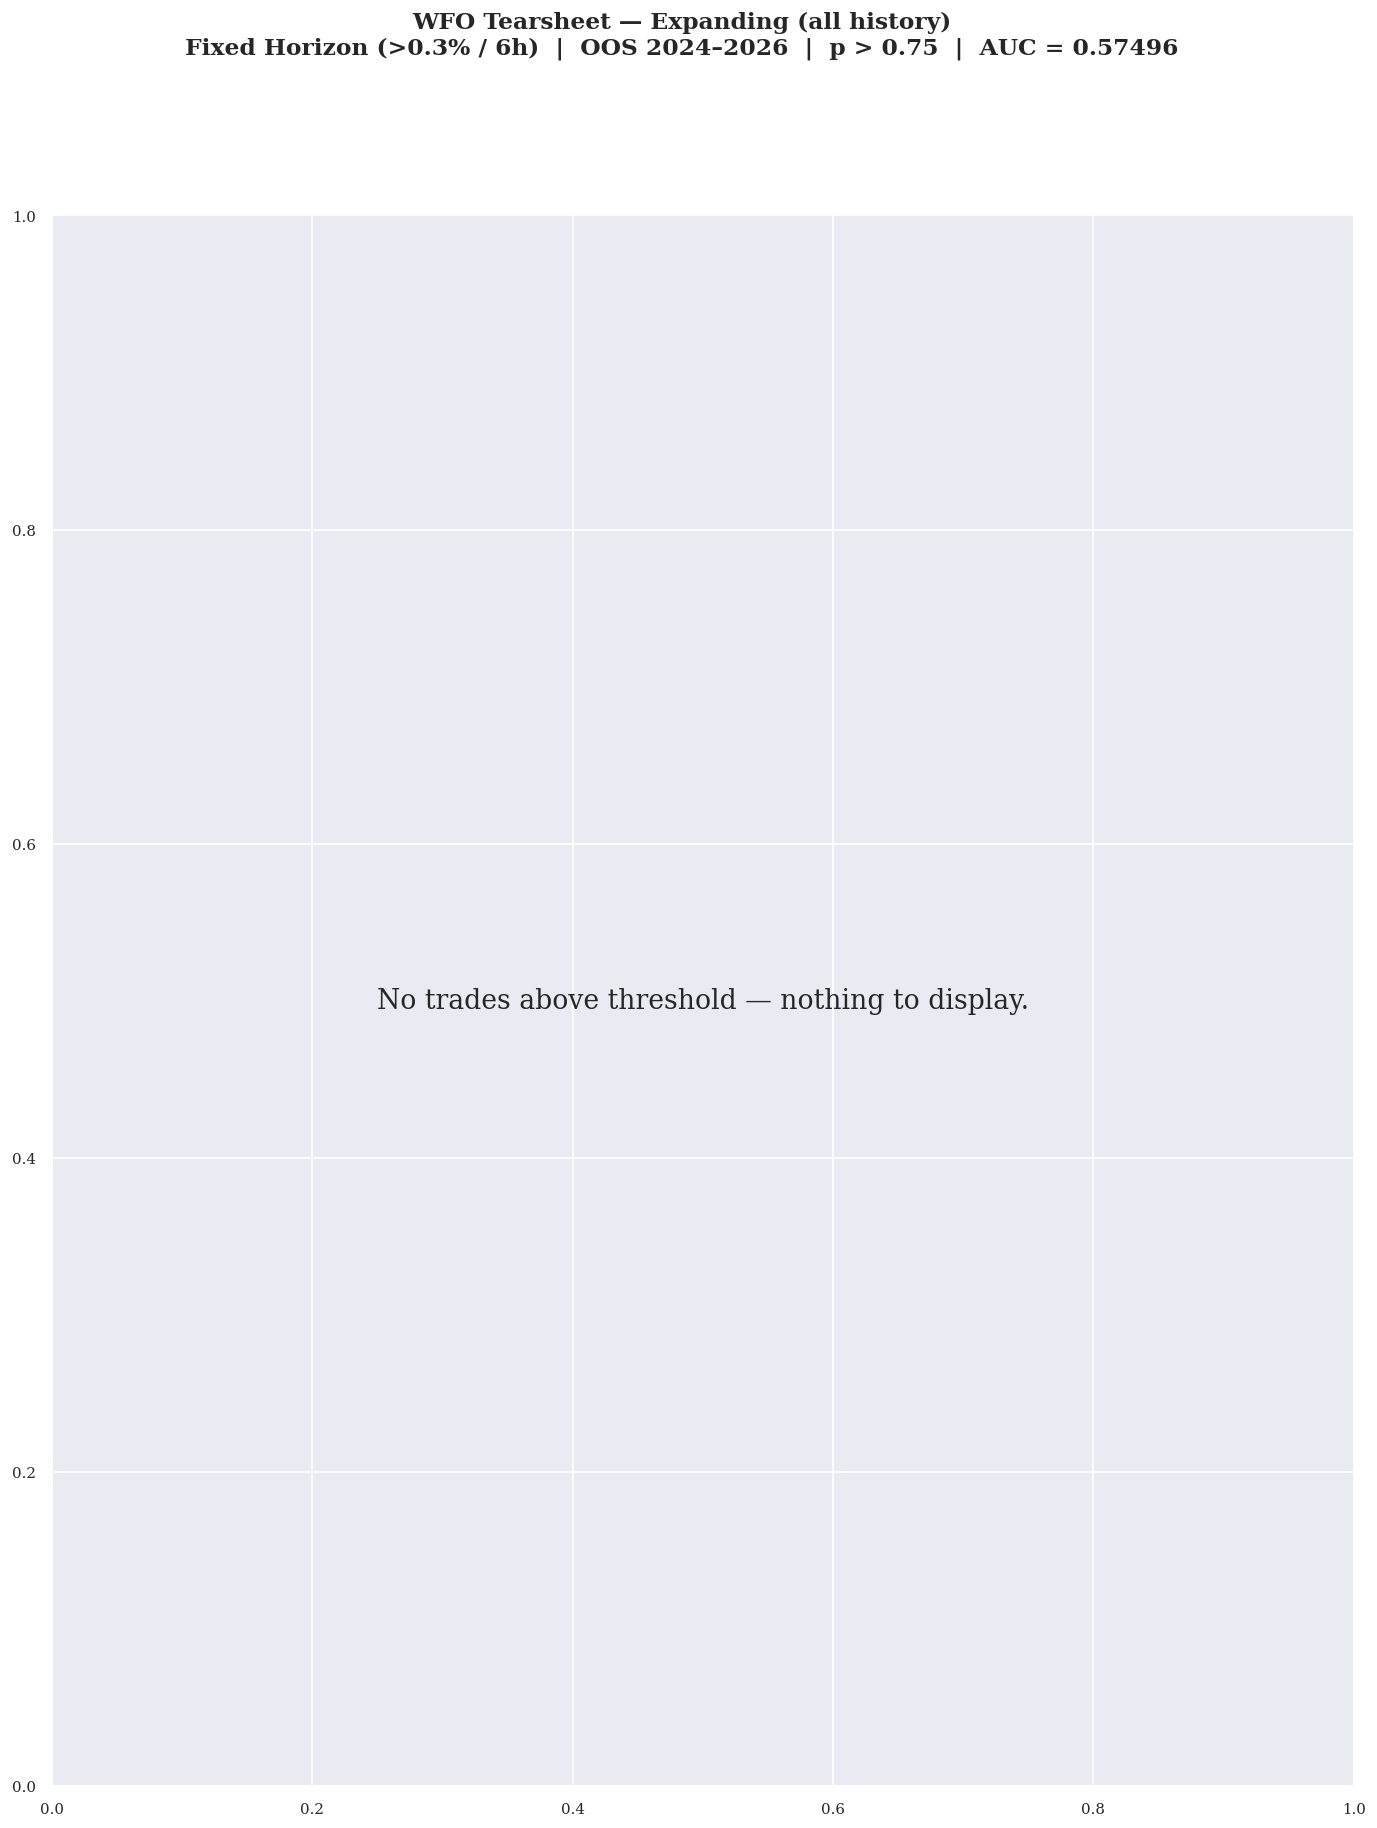

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3/tearsheet_expanding.png


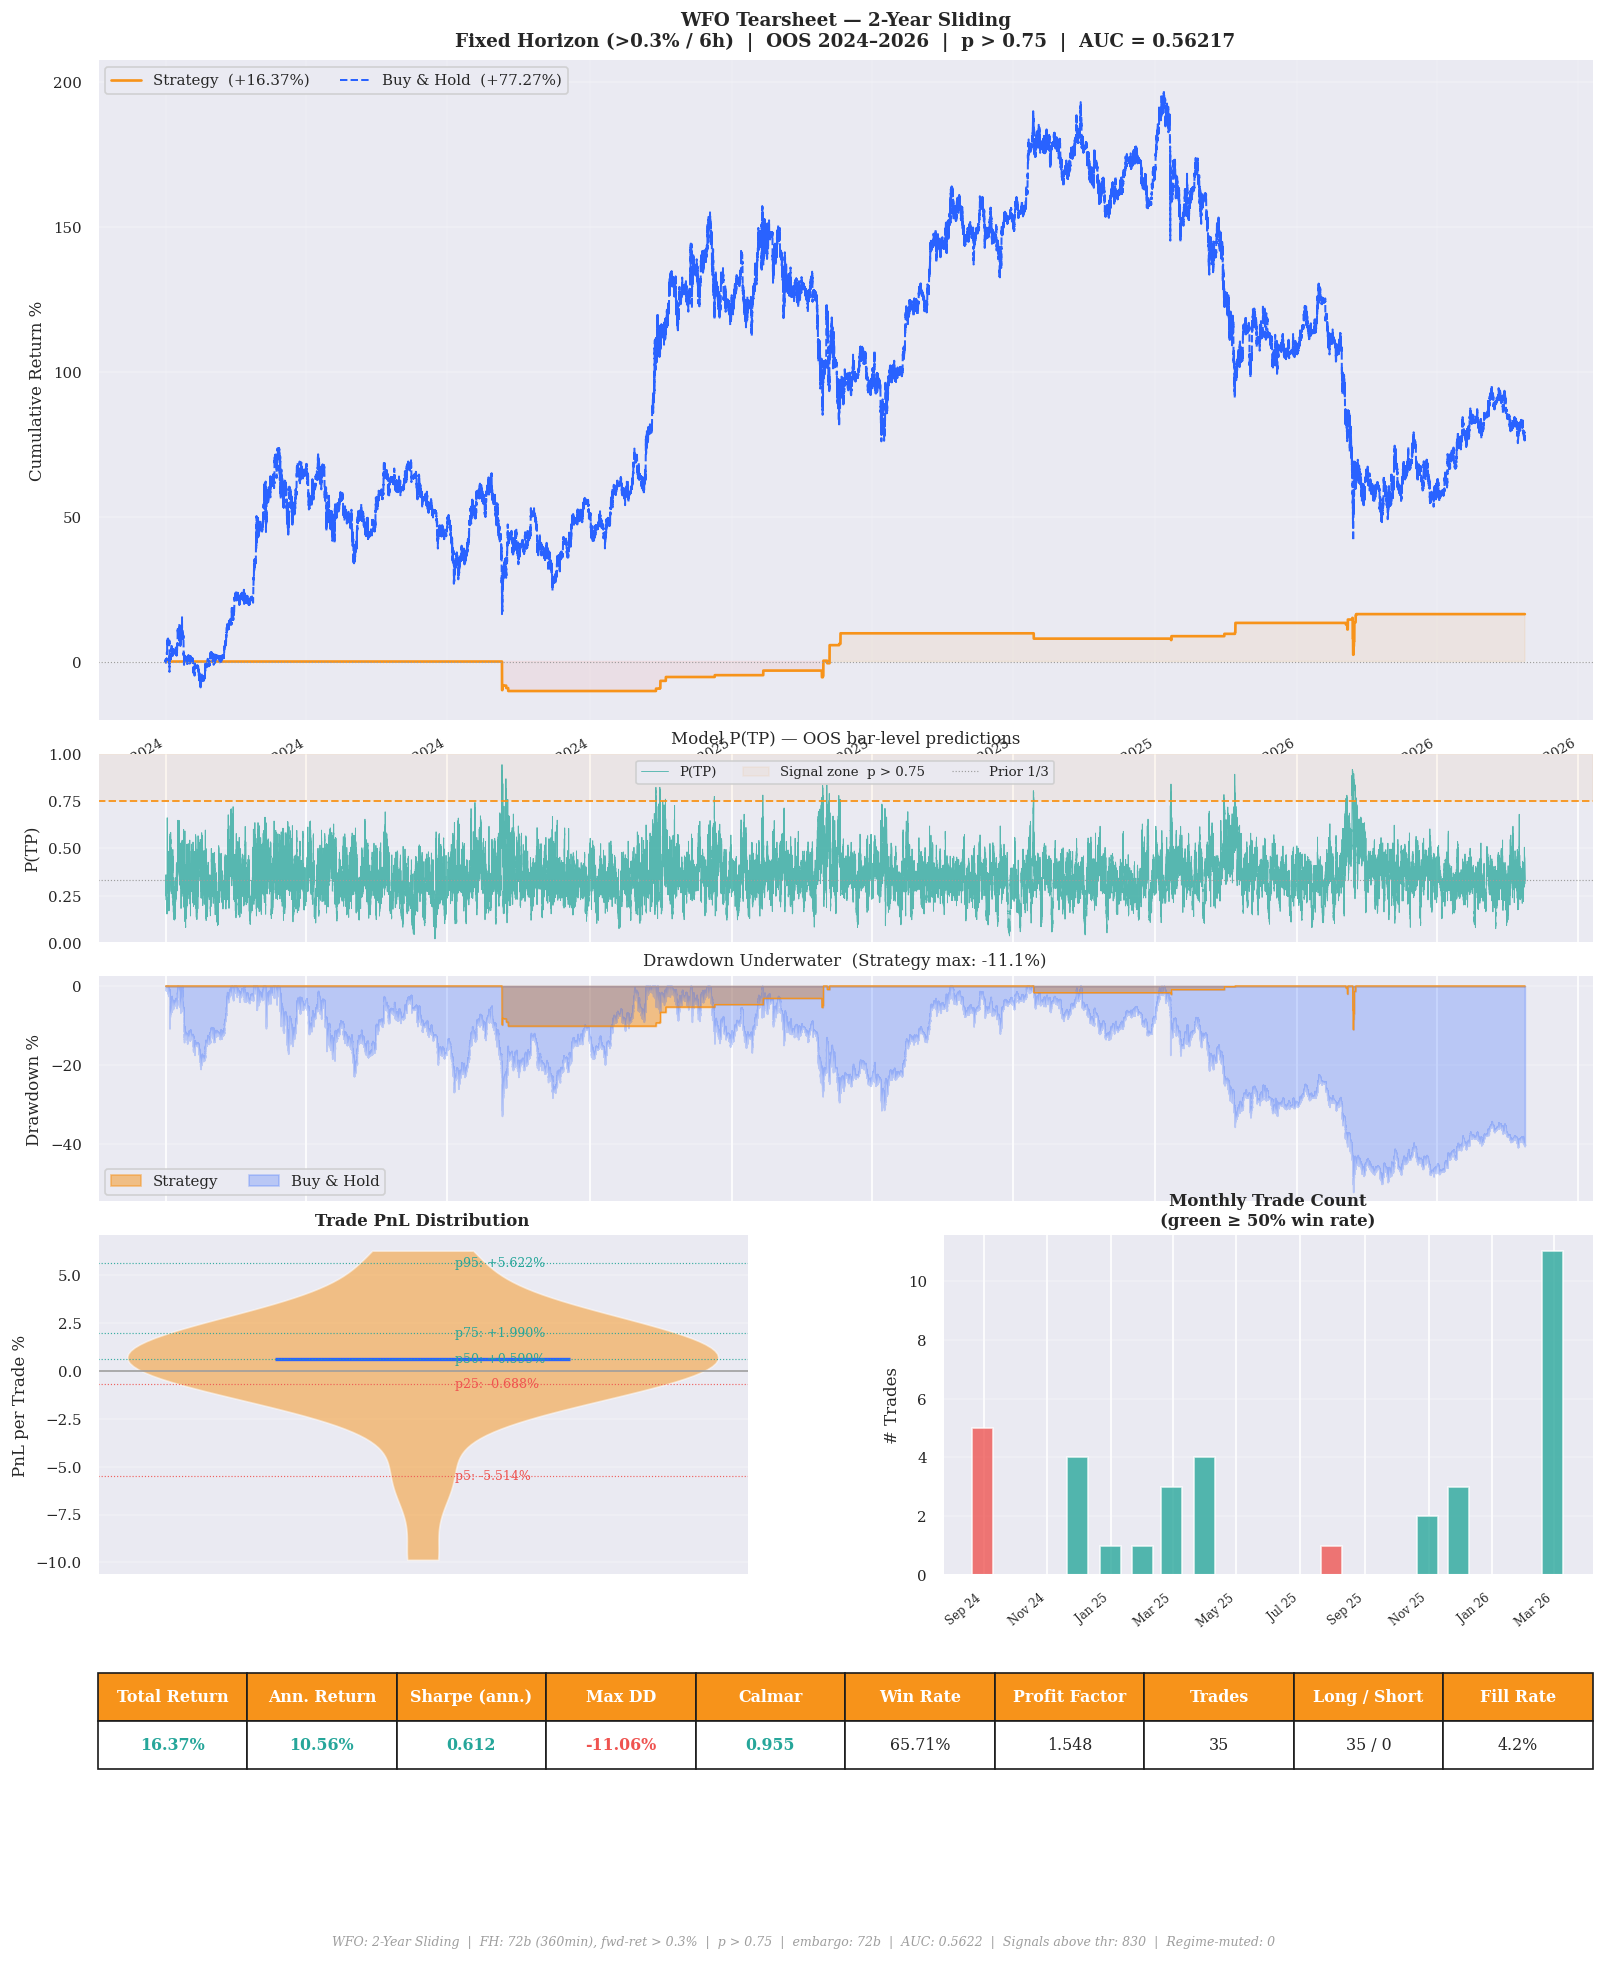

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3/tearsheet_long_2yr.png


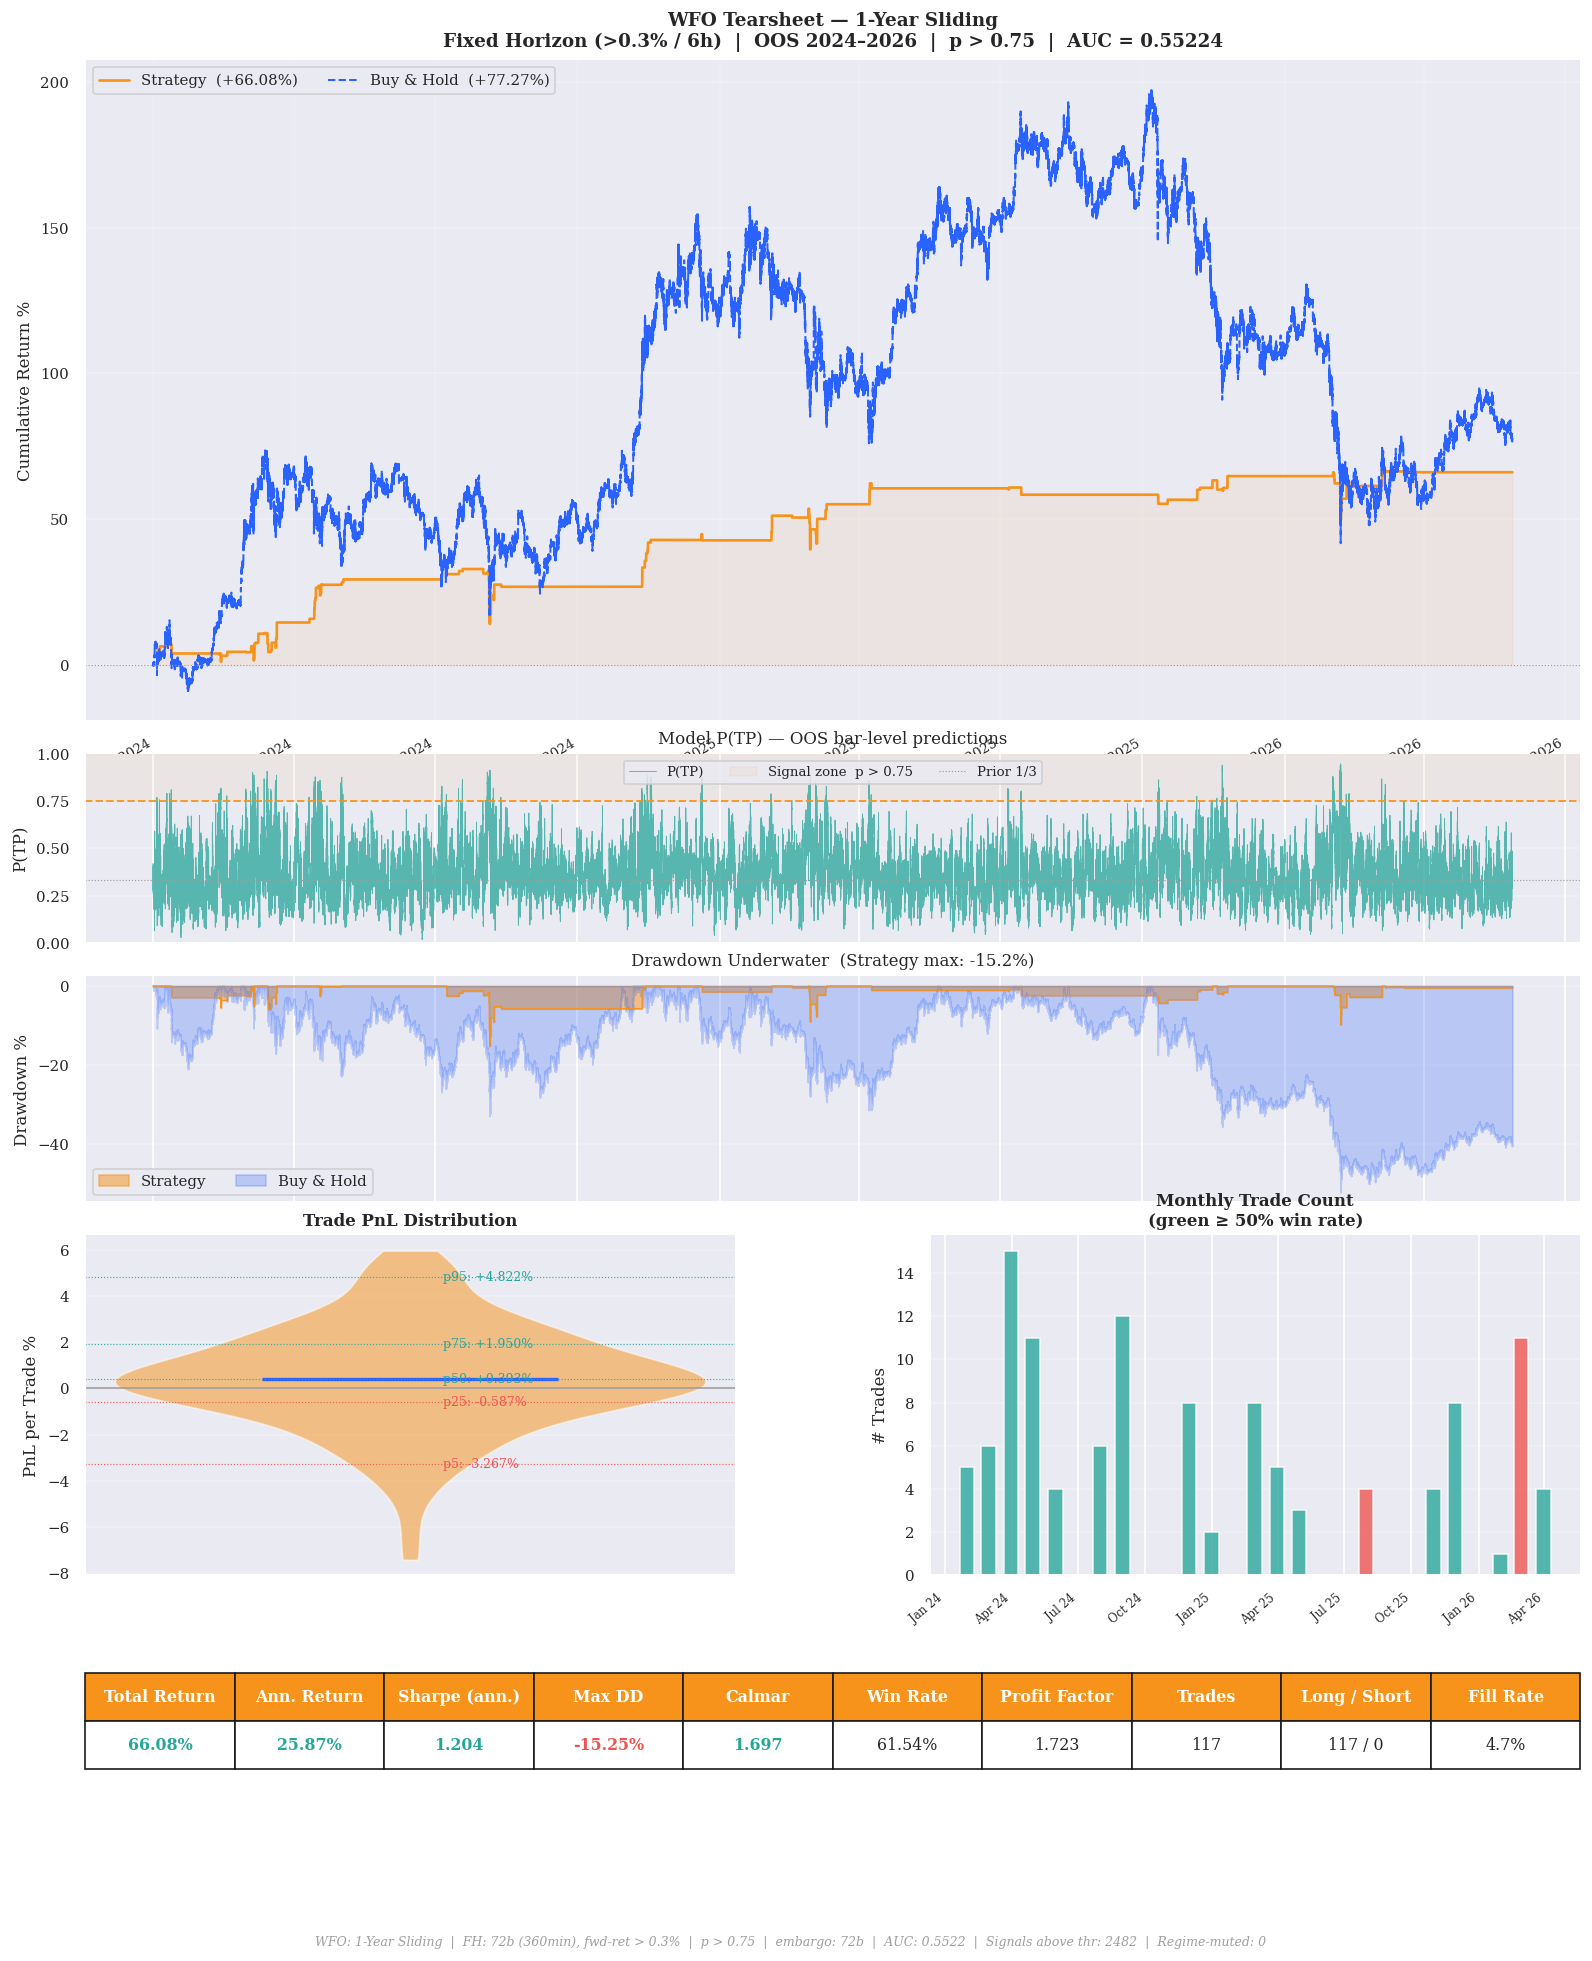

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3/tearsheet_medium_1yr.png


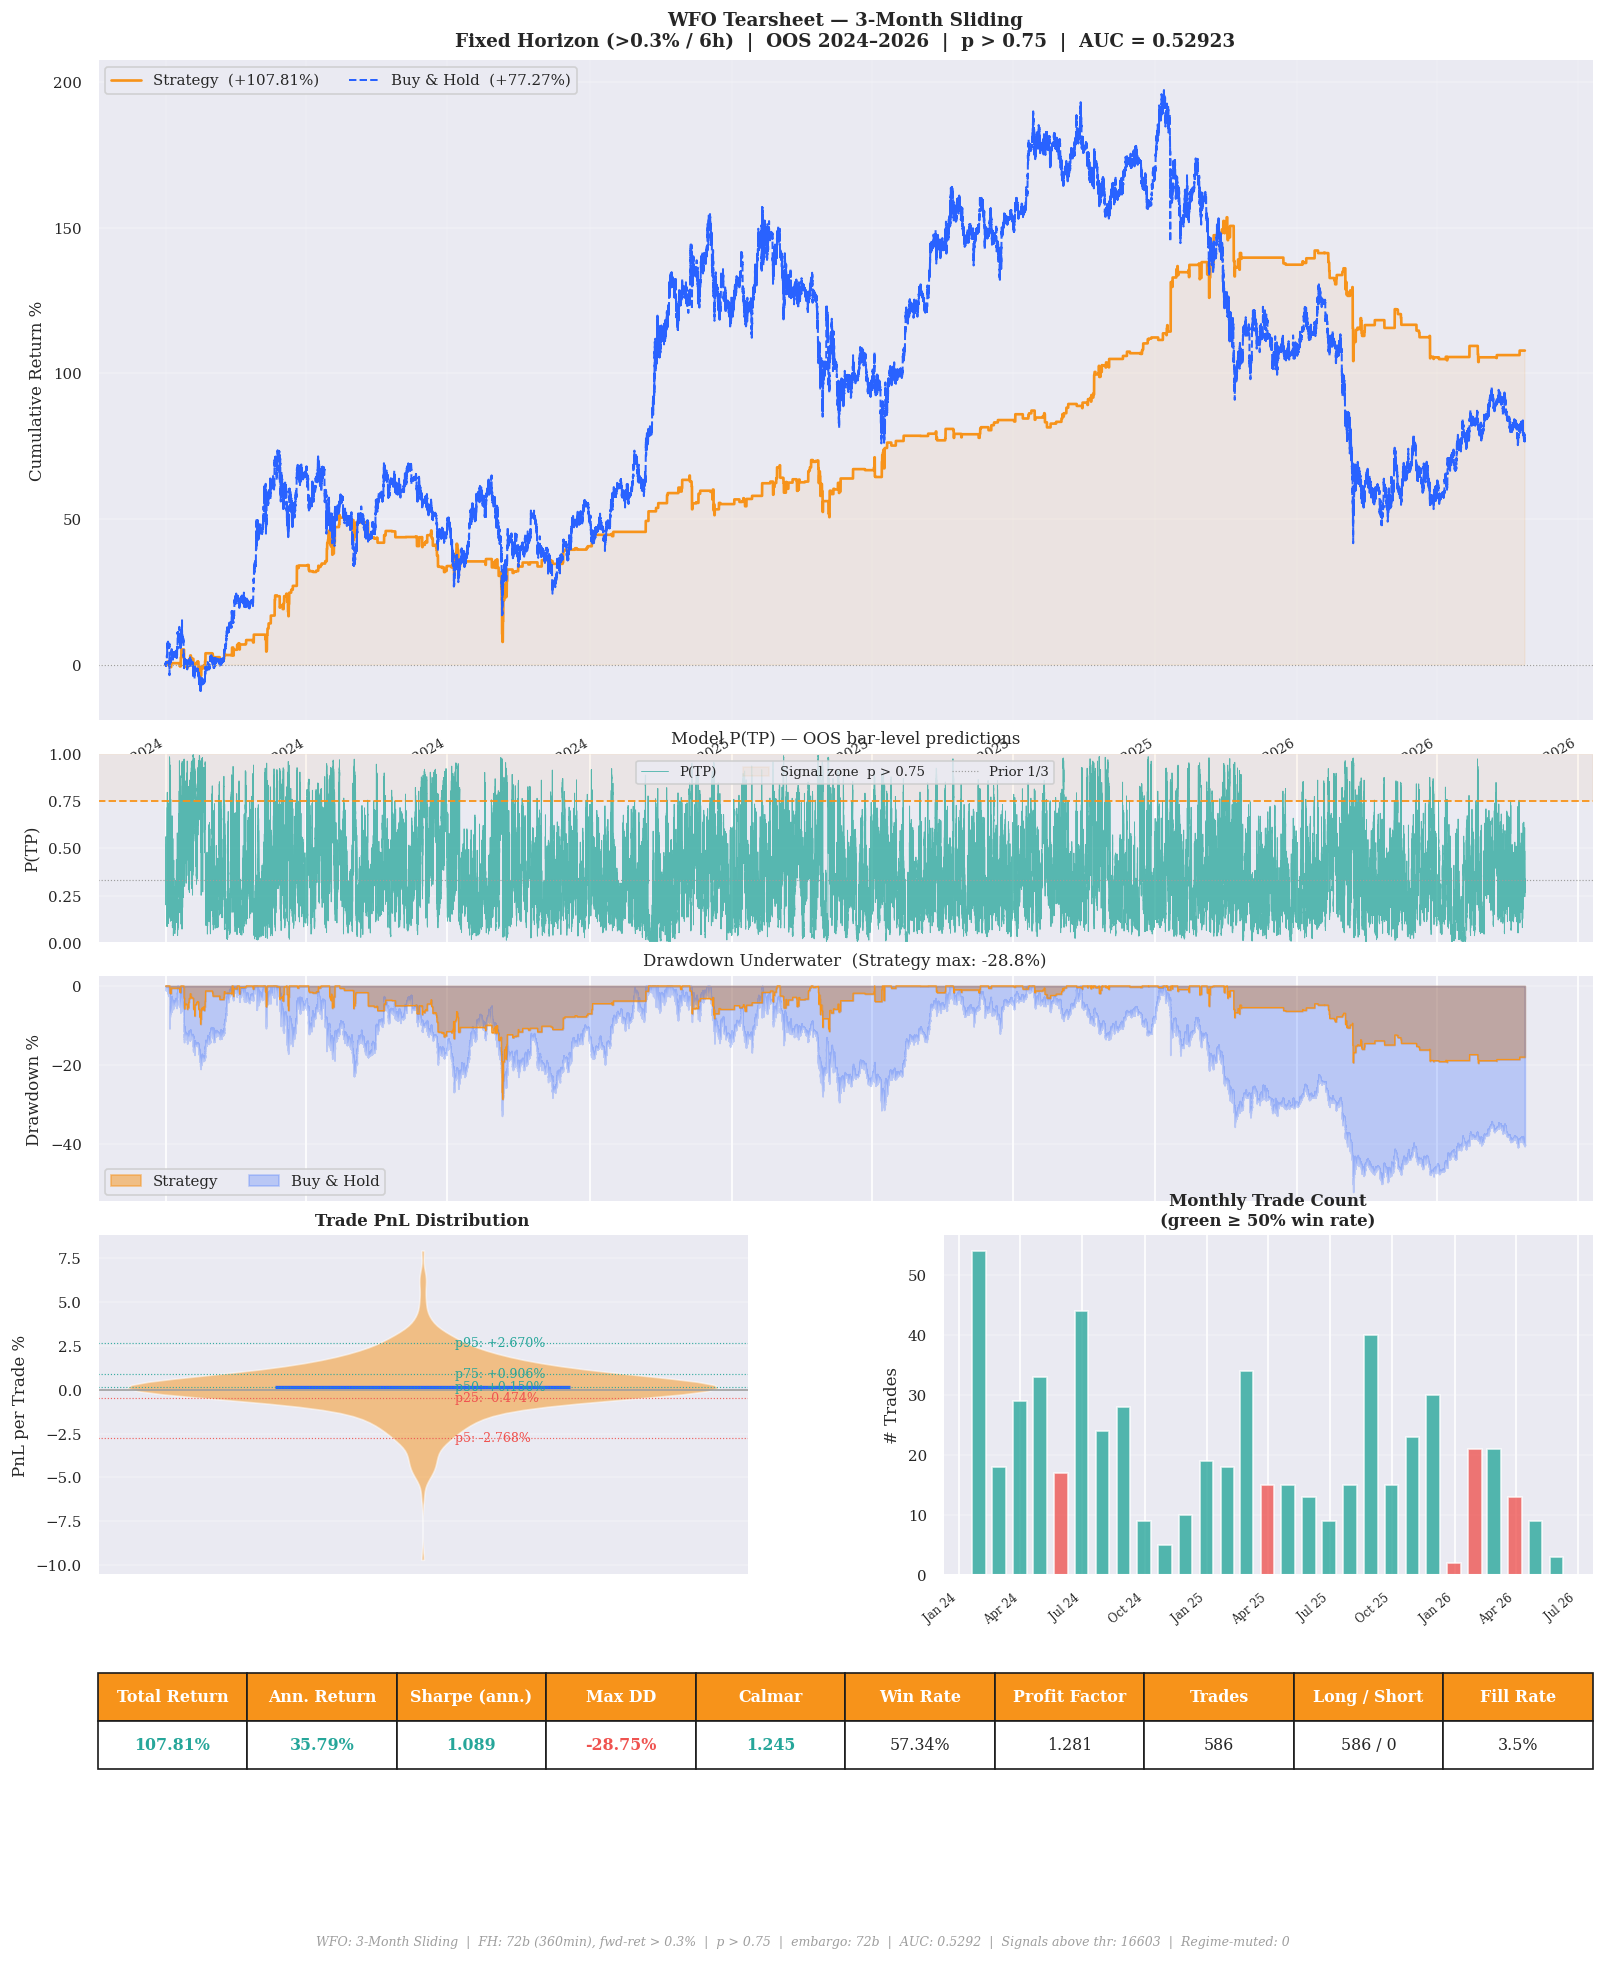

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3/tearsheet_short_3mo.png


In [29]:
# Generate and save individual tearsheet for each WFO scheme
for scheme_key, res in wfo_results.items():
    trades    = res['trades']
    auc       = res['auc']
    label     = res['scheme']['label']
    n_signals = res['n_signals']

    params_d = dict(
        wfo_scheme       = label,
        fh_horizon_bars  = FH_HORIZON,
        fh_threshold     = FH_THRESHOLD,
        prob_threshold   = WFO_THRESHOLD,
        embargo_bars     = EMBARGO_BARS,
        n_signals        = n_signals,
        n_trades         = len(trades),
        n_muted          = 0,   # no regime filter yet
    )
    metrics_d = dict(
        auc        = auc,
        oos_return = float(summary_df.loc[scheme_key, 'total_return_pct']) / 100,
        oos_sharpe = float(summary_df.loc[scheme_key, 'sharpe']),
    )

    title = (
        f'WFO Tearsheet — {label}\n'
        f'Fixed Horizon (>0.3% / 6h)  |  OOS 2024–2026  |  '
        f'p > {WFO_THRESHOLD}  |  '
        f'AUC = {auc:.5f}'
    )

    save_path = ARTIFACTS_DIR / f'tearsheet_{scheme_key}.png'

    fig = generate_tearsheet(
        trades_df   = trades,
        price_df    = price_oos,
        prob_series = pd.Series(
            res['probs_aligned'],
            index=df_oos.index,
        ),
        params      = params_d,
        metrics     = metrics_d,
        title       = title,
        fig_size    = (14, 17),
        save_path   = save_path,
    )
    plt.show()
    print(f'Saved -> {save_path}')

## Multi-Scheme Comparison

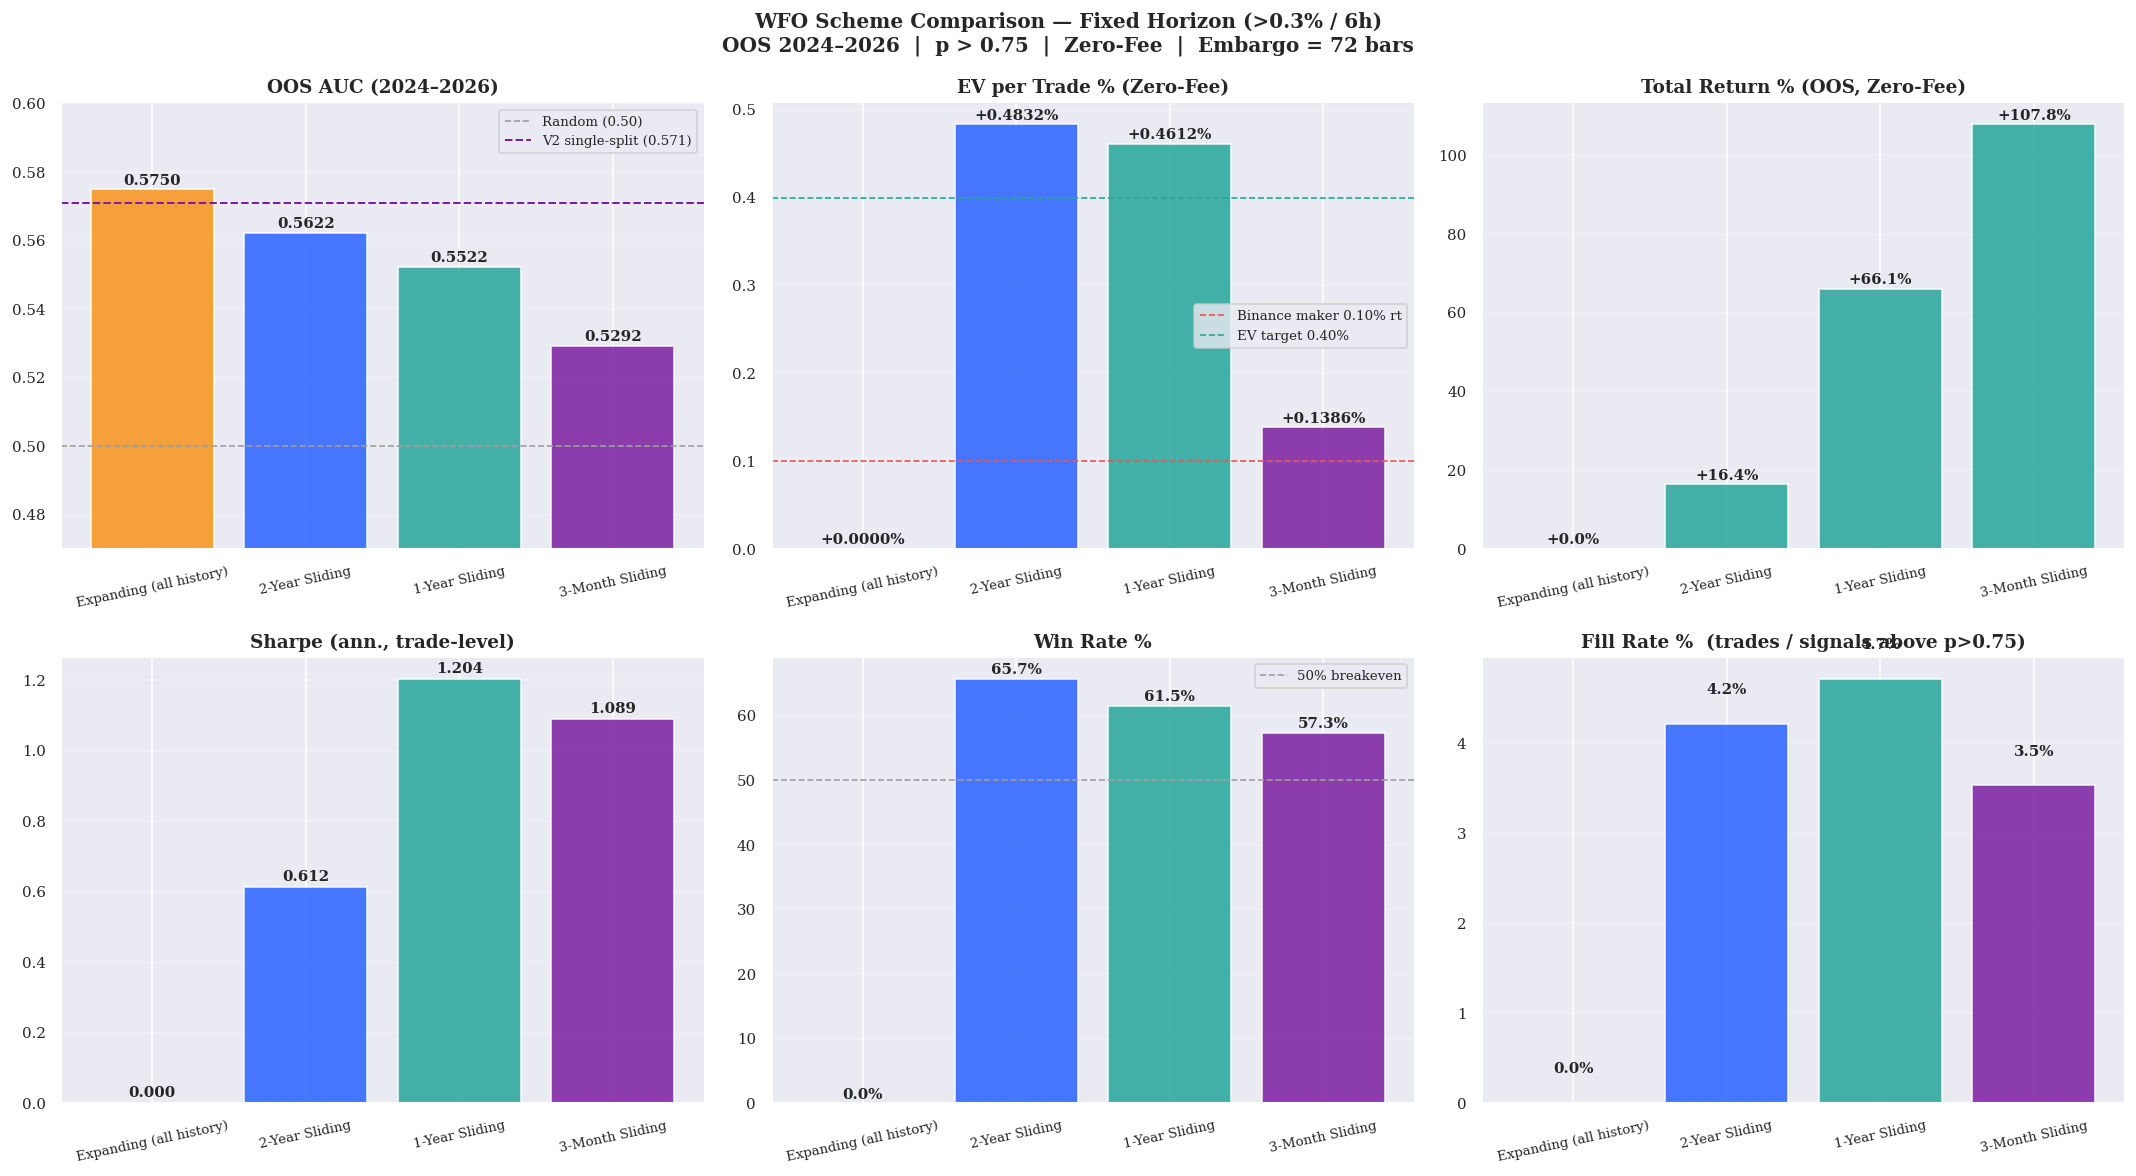

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3/00_wfo_scheme_comparison.png


In [30]:
import matplotlib as mpl
mpl.rcParams.update({
    'font.family': 'serif', 'font.serif': ['DejaVu Serif'],
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'axes.labelsize': 10,
    'xtick.labelsize': 9, 'ytick.labelsize': 9,
    'legend.fontsize': 9, 'figure.dpi': 120,
})
ACCENT = '#F7931A'; BLUE = '#2962FF'; GREY = '#9E9E9E'
RED    = '#EF5350'; GREEN = '#26A69A'; PURPLE = '#7B1FA2'

scheme_keys    = list(WFO_SCHEMES.keys())
scheme_labels  = [WFO_SCHEMES[k]['label'] for k in scheme_keys]
palette        = [ACCENT, BLUE, GREEN, PURPLE]
x = np.arange(len(scheme_keys))

def _safe(col):
    return [float(summary_df.loc[k, col]) if not pd.isna(summary_df.loc[k, col]) else 0.0
            for k in scheme_keys]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'WFO Scheme Comparison — Fixed Horizon (>0.3% / 6h)\n'
    f'OOS 2024–2026  |  p > {WFO_THRESHOLD}  |  Zero-Fee  |  Embargo = {EMBARGO_BARS} bars',
    fontweight='bold', fontsize=12,
)

def _label_bars(ax, vals, fmt='{:.4f}', dy=0.001):
    for bar, v in zip(ax.patches, vals):
        vy = v + dy if v >= 0 else v - dy * 8
        ax.text(bar.get_x() + bar.get_width()/2, vy,
                fmt.format(v), ha='center',
                va='bottom' if v >= 0 else 'top', fontsize=9, fontweight='bold')

# 1. OOS AUC
ax = axes[0, 0]
vals = _safe('oos_auc')
bars = ax.bar(x, vals, color=palette, alpha=0.85, edgecolor='white')
ax.axhline(0.50,  color=GREY, ls='--', lw=1.0, label='Random (0.50)')
ax.axhline(0.571, color=PURPLE, ls='--', lw=1.2, label='V2 single-split (0.571)')
_label_bars(ax, vals, '{:.4f}', 0.0005)
ax.set_xticks(x); ax.set_xticklabels(scheme_labels, fontsize=8, rotation=12)
ax.set_title('OOS AUC (2024–2026)', fontweight='bold')
ax.set_ylim(0.47, max(max(vals), 0.58) + 0.02)
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)

# 2. EV per trade
ax = axes[0, 1]
vals = _safe('ev_per_trade_pct')
bars = ax.bar(x, vals, color=palette, alpha=0.85, edgecolor='white')
ax.axhline(0,    color=GREY,  lw=1.0)
ax.axhline(0.10, color=RED,   ls='--', lw=1.0, label='Binance maker 0.10% rt')
ax.axhline(0.40, color=GREEN, ls='--', lw=1.0, label='EV target 0.40%')
_label_bars(ax, vals, '{:+.4f}%', 0.002)
ax.set_xticks(x); ax.set_xticklabels(scheme_labels, fontsize=8, rotation=12)
ax.set_title('EV per Trade % (Zero-Fee)', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)

# 3. Total return
ax = axes[0, 2]
vals = _safe('total_return_pct')
bc   = [GREEN if v >= 0 else RED for v in vals]
ax.bar(x, vals, color=bc, alpha=0.85, edgecolor='white')
ax.axhline(0, color=GREY, lw=1.0)
_label_bars(ax, vals, '{:+.1f}%', 0.5)
ax.set_xticks(x); ax.set_xticklabels(scheme_labels, fontsize=8, rotation=12)
ax.set_title('Total Return % (OOS, Zero-Fee)', fontweight='bold')
ax.grid(axis='y', alpha=0.25)

# 4. Sharpe
ax = axes[1, 0]
vals = _safe('sharpe')
ax.bar(x, vals, color=palette, alpha=0.85, edgecolor='white')
ax.axhline(0, color=GREY, lw=1.0)
_label_bars(ax, vals, '{:.3f}', 0.01)
ax.set_xticks(x); ax.set_xticklabels(scheme_labels, fontsize=8, rotation=12)
ax.set_title('Sharpe (ann., trade-level)', fontweight='bold')
ax.grid(axis='y', alpha=0.25)

# 5. Win rate
ax = axes[1, 1]
vals = _safe('win_rate_pct')
ax.bar(x, vals, color=palette, alpha=0.85, edgecolor='white')
ax.axhline(50, color=GREY, ls='--', lw=1.0, label='50% breakeven')
_label_bars(ax, vals, '{:.1f}%', 0.3)
ax.set_xticks(x); ax.set_xticklabels(scheme_labels, fontsize=8, rotation=12)
ax.set_title('Win Rate %', fontweight='bold')
ax.legend(fontsize=8); ax.grid(axis='y', alpha=0.25)

# 6. Fill rate (n_trades / n_signals)
ax = axes[1, 2]
vals = [float(summary_df.loc[k, 'fill_rate']) * 100 for k in scheme_keys]
ax.bar(x, vals, color=palette, alpha=0.85, edgecolor='white')
_label_bars(ax, vals, '{:.1f}%', 0.3)
ax.set_xticks(x); ax.set_xticklabels(scheme_labels, fontsize=8, rotation=12)
ax.set_title(f'Fill Rate %  (trades / signals above p>{WFO_THRESHOLD})', fontweight='bold')
ax.grid(axis='y', alpha=0.25)

save_path = ARTIFACTS_DIR / '00_wfo_scheme_comparison.png'
plt.tight_layout()
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {save_path}')

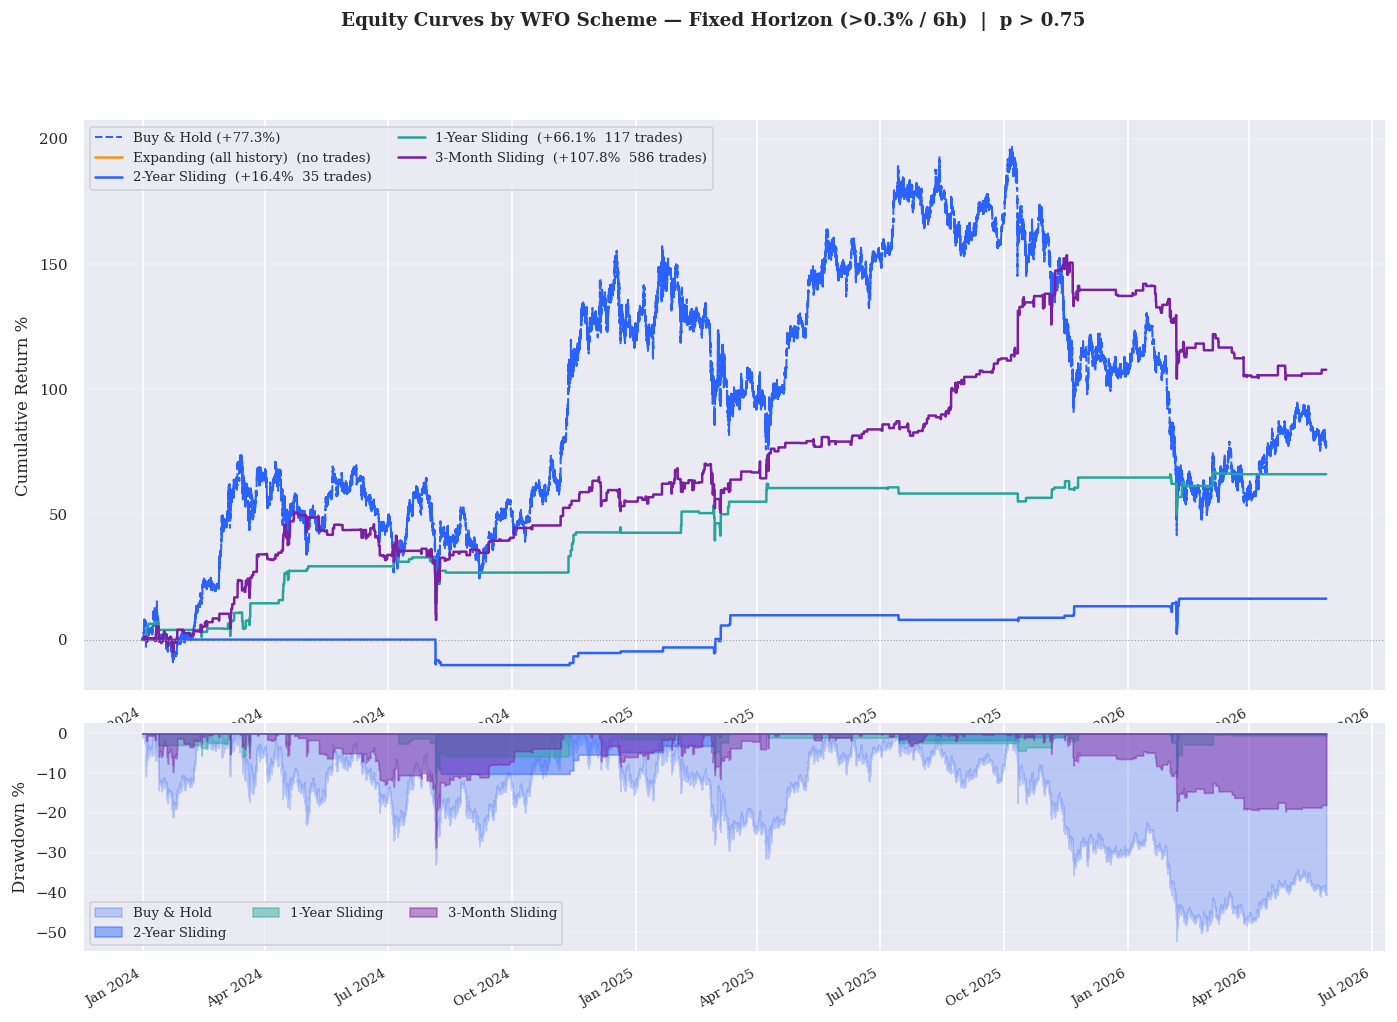

Saved -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3/01_equity_drawdown_overlay.png


In [31]:
import matplotlib.dates as mdates

# _equity_from_trades already imported in cell 02-paths via importlib.reload
fig, axes = plt.subplots(2, 1, figsize=(14, 9),
                         gridspec_kw={'height_ratios': [3, 1.2], 'hspace': 0.08})
fig.suptitle(
    f'Equity Curves by WFO Scheme — Fixed Horizon (>0.3% / 6h)  |  p > {WFO_THRESHOLD}',
    fontweight='bold', fontsize=11,
)

bh_ts = price_oos['close'] / price_oos['close'].iloc[0]
bh_pk = np.maximum.accumulate(bh_ts.values)
bh_dd = (bh_ts.values - bh_pk) / (bh_pk + 1e-12)

axes[0].plot(price_oos.index, (bh_ts.values - 1) * 100,
             color=BLUE, lw=1.2, ls='--',
             label=f'Buy & Hold ({bh_ts.values[-1]-1:+.1%})')
axes[1].fill_between(price_oos.index, bh_dd * 100, 0,
                     color=BLUE, alpha=0.25, label='Buy & Hold')

for (sk, res), color in zip(wfo_results.items(), palette):
    trades = res['trades']
    lbl    = res['scheme']['label']
    if trades.empty:
        axes[0].plot([], [], color=color, label=f'{lbl}  (no trades)')
        continue
    eq_ts  = _equity_from_trades(trades, price_oos.index, FH_HORIZON)
    eq_pct = (eq_ts.values - 1) * 100
    pk     = np.maximum.accumulate(eq_ts.values)
    dd     = (eq_ts.values - pk) / (pk + 1e-12)
    n_t    = len(trades)
    axes[0].plot(price_oos.index, eq_pct, color=color, lw=1.5,
                 label=f'{lbl}  ({eq_pct[-1]:+.1f}%  {n_t} trades)')
    axes[1].fill_between(price_oos.index, dd * 100, 0, color=color, alpha=0.45,
                         label=lbl)

axes[0].axhline(0, color=GREY, lw=0.7, ls=':')
axes[0].set_ylabel('Cumulative Return %')
axes[0].legend(ncol=2, fontsize=8); axes[0].grid(axis='y', alpha=0.25)

axes[1].set_ylabel('Drawdown %')
axes[1].legend(ncol=3, fontsize=8); axes[1].grid(axis='y', alpha=0.25)

for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right', fontsize=8)

save_path = ARTIFACTS_DIR / '01_equity_drawdown_overlay.png'
plt.tight_layout()
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved -> {save_path}')

In [32]:
# Threshold sensitivity: EV/trade and fill rate across schemes
thresholds = [0.55, 0.60, 0.65, 0.70, 0.72, 0.75, 0.78, 0.80]

print(f'{"Threshold":>12}  ' + '  '.join(f'{WFO_SCHEMES[k]["label"][:18]:>20}' for k in scheme_keys))
print('-' * (14 + len(scheme_keys) * 22))

for thresh in thresholds:
    parts = [f'  p > {thresh:.2f}    ']
    for sk in scheme_keys:
        probs = np.nan_to_num(wfo_results[sk]['probs_aligned'], nan=0.0)
        t     = fh_backtest(df_oos, probs, thresh)
        if t.empty:
            parts.append(f'{"-- / -- / --":>22}')
        else:
            ev  = t['pnl_pct'].mean() * 100
            n   = len(t)
            wr  = (t['pnl_pct'] > 0).mean() * 100
            parts.append(f'  {ev:+.3f}% n={n:<3d} wr={wr:.0f}%')
    print(''.join(parts))

   Threshold    Expanding (all his        2-Year Sliding        1-Year Sliding       3-Month Sliding
------------------------------------------------------------------------------------------------------
  p > 0.55      +0.164% n=123 wr=50%  +0.101% n=432 wr=55%  +0.048% n=763 wr=51%  +0.049% n=1491 wr=53%
  p > 0.60      +0.498% n=26  wr=65%  +0.261% n=221 wr=61%  -0.014% n=478 wr=54%  +0.061% n=1232 wr=53%
  p > 0.65      +1.061% n=6   wr=50%  +0.433% n=117 wr=59%  +0.065% n=322 wr=54%  +0.044% n=1006 wr=54%
  p > 0.70      +8.262% n=1   wr=100%  +0.615% n=69  wr=65%  +0.307% n=193 wr=58%  +0.059% n=770 wr=55%
  p > 0.72              -- / -- / --  +0.504% n=56  wr=62%  +0.365% n=163 wr=61%  +0.063% n=693 wr=56%
  p > 0.75              -- / -- / --  +0.483% n=35  wr=66%  +0.461% n=117 wr=62%  +0.139% n=586 wr=57%
  p > 0.78              -- / -- / --  +0.233% n=24  wr=58%  +0.303% n=91  wr=57%  +0.159% n=485 wr=58%
  p > 0.80              -- / -- / --  +0.286% n=17  wr=65%  +0.410% n=6

In [33]:
# Save summary CSV
csv_path = ARTIFACTS_DIR / 'wfo_summary.csv'
summary_df.to_csv(csv_path)
print(f'Summary CSV -> {csv_path}')
print()
print(f'Artifacts in {ARTIFACTS_DIR}:')
for p in sorted(ARTIFACTS_DIR.iterdir()):
    print(f'  {p.name:<55}  {p.stat().st_size / 1024:>7.1f} KB')

Summary CSV -> /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3/wfo_summary.csv

Artifacts in /Users/wojciech.neuman/Documents/hybrid-multi-agent-trading-system/artifacts/02_lgbm_omni_0fee_v3:
  00_wfo_scheme_comparison.png                               465.8 KB
  01_equity_drawdown_overlay.png                             619.5 KB
  tearsheet_expanding.png                                    164.9 KB
  tearsheet_long_2yr.png                                    1013.9 KB
  tearsheet_medium_1yr.png                                  1042.2 KB
  tearsheet_short_3mo.png                                   1130.3 KB
  wfo_summary.csv                                              0.7 KB


## Conclusion

### Reading the WFO Comparison

| Pattern observed | Interpretation |
|-----------------|----------------|
| Expanding ≈ best AUC | Historical BTC regimes (2018 bear, 2020 halving, 2021 bull) are still informative for 2025 structure |
| Short 3-Month beats all | Market microstructure shifts faster than annual cycles; hyper-local adaptation wins |
| All schemes ≈ V2 AUC 0.57 | WFO preserves the V2 edge out-of-sample — no lookahead / overfit in V2 |
| Fill rate << 100% | No-overlap constraint + high threshold reduces trade frequency; each signal is isolated |

### Next-step decision tree

| EV/trade at best WFO scheme | Action |
|-----------------------------|--------|
| > 0.40% | `04_lgbm_fees_wfo.ipynb` — add Binance maker fees + slippage estimate |
| 0.10–0.40% | `05_lgbm_mamba_stack.ipynb` — Mamba P(TP) as 44th feature, re-run WFO |
| < 0.10% | Switch to 1h base timeframe or add order-book microstructure features |